In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df=pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

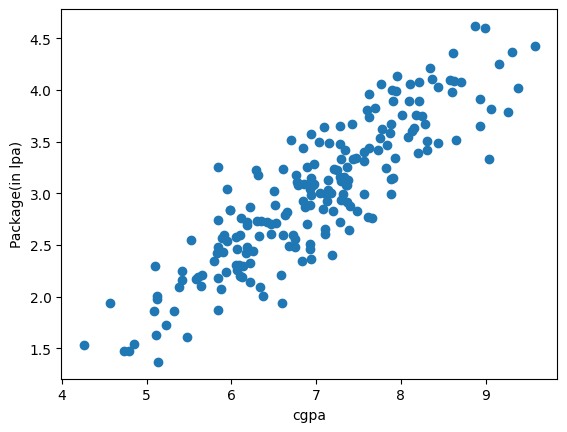

In [4]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('Package(in lpa)')

In [5]:
X=df.iloc[:,0:1]  #fetch all row and zero to 1 column
Y=df.iloc[:,-1]   # fetch all row and last column (output column)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)

LinearRegression()

In [9]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

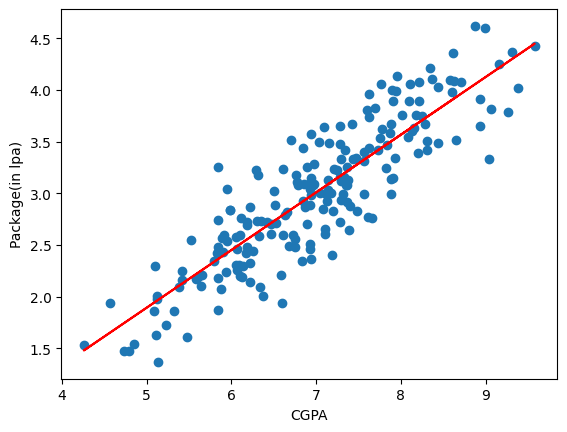

In [10]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [13]:
m = lr.coef_
m

array([0.55795197])

In [14]:
b = lr.intercept_
b

np.float64(-0.8961119222429144)

In [22]:
# y = mx + b

m * 8.58 + b

array([3.89111601])

In [27]:
y_pred=lr.predict(X_test)
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [30]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.780730147510384

In [48]:
from sklearn.linear_model import Ridge
rr=Ridge(alpha=0.00001)
rr.fit(X_train,y_train)

Ridge(alpha=1e-05)

In [49]:
Y_pred=rr.predict(X_test)
Y_pred

array([3.89111596, 3.09324468, 2.38464572, 2.57434938, 1.65372867,
       1.7764781 , 2.07219263, 2.93143862, 3.76278701, 2.93701814,
       4.09197866, 3.51170864, 2.97049526, 2.40138427, 3.18809651,
       3.46707248, 1.94386368, 3.24389171, 2.97607477, 3.41685681,
       2.55761082, 3.16577844, 2.85890487, 3.12114228, 3.68467374,
       2.87006391, 3.49497008, 3.34432306, 3.91901356, 1.96060224,
       3.65119663, 3.21041459, 3.74046894, 2.78637111, 2.78079159,
       3.2717893 , 3.5284472 , 2.61340601, 2.65804217, 2.71383736])

In [50]:
r2 = r2_score(y_test, Y_pred)
r2

0.7807301401478199

In [20]:
class MeraLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        X_train = X_train.values.flatten()
        y_train = y_train.values.flatten()

        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))
        
        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)       
    
    def predict(self,X_test):
        
        print(X_test)
        
        return self.m * X_test + self.b

In [21]:
lr = MeraLR()

In [22]:
lr.fit(X_train,y_train)

0.5579519734250721
-0.8961119222429152


In [27]:
lr.predict(X_test)

     cgpa
112  8.58
29   7.15
182  5.88
199  6.22
193  4.57
85   4.79
10   5.32
54   6.86
115  8.35
35   6.87
12   8.94
92   7.90
13   6.93
126  5.91
174  7.32
2    7.82
44   5.09
3    7.42
113  6.94
14   7.73
23   6.19
25   7.28
6    6.73
134  7.20
165  8.21
173  6.75
45   7.87
65   7.60
48   8.63
122  5.12
178  8.15
64   7.36
9    8.31
57   6.60
78   6.59
71   7.47
128  7.93
176  6.29
131  6.37
53   6.47


,cgpa
112,3.891116
29,3.093245
182,2.384646
199,2.574349
193,1.653729
85,1.776478
10,2.072193
54,2.931439
115,3.762787
35,2.937018
